# Lesson 2.2 — Finite Volume Method (FVM)

## The Bathtub Analogy

Forget derivatives. Instead, look at each cell of the mesh as a small bathtub.
The water level (scalar quantity) changes only because of:

1. **Flux in** through the left and bottom faces
2. **Flux out** through the right and top faces
3. **Sources/sinks** inside the cell

The FVM never approximates derivatives inside cells — it only computes fluxes *through faces*.
This makes it naturally conservative: what leaves one cell enters the next. No mass is
created or destroyed by the numerics.

This is the reason FVM is the dominant method in industrial CFD (OpenFOAM, ANSYS Fluent).

---

## The Integral Conservation Form

Integrate the conservation law over a control volume $V_i$:

$$\frac{d}{dt} \int_{V_i} u \, dV = -\oint_{\partial V_i} \mathbf{F} \cdot \hat{n} \, dS + \int_{V_i} S \, dV$$

For a 2D cell of size $\Delta x \times \Delta y$, the surface integral becomes a sum of face fluxes:

$$\Delta x \Delta y \frac{d \bar{u}_i}{dt} = F_{\text{left}} - F_{\text{right}} + F_{\text{bottom}} - F_{\text{top}}$$

where $\bar{u}_i$ is the cell-average and $F_{\text{face}}$ is the flux through each face.

---

## Face Flux Reconstruction

The key problem: $\bar{u}_i$ lives at cell centres but we need the flux at cell faces.
How to interpolate?

**Upwind scheme** (1st order): use the cell value from the upwind direction:
$$F_{i+1/2} = c \cdot u_i \quad (c > 0)$$

**Central scheme** (2nd order): average the two neighbours:
$$F_{i+1/2} = c \cdot \frac{u_i + u_{i+1}}{2}$$

**Linear reconstruction + limiting** (higher order, Module 03): reconstruct a linear profile
inside each cell, limiting the slope to prevent overshoots.

---

## FVM vs. FDM

| Property | FDM | FVM |
|----------|-----|-----|
| Approximates | Derivatives pointwise | Integrals over cells |
| Conservation | Not guaranteed | Exact (by construction) |
| Grid types | Structured (easy) | Structured + unstructured |
| Industry use | Research, simple flows | Standard in engineering CFD |

FDM (Module 01) is conceptually simpler and mathematically cleaner for analysis.
FVM is what you use in practice.


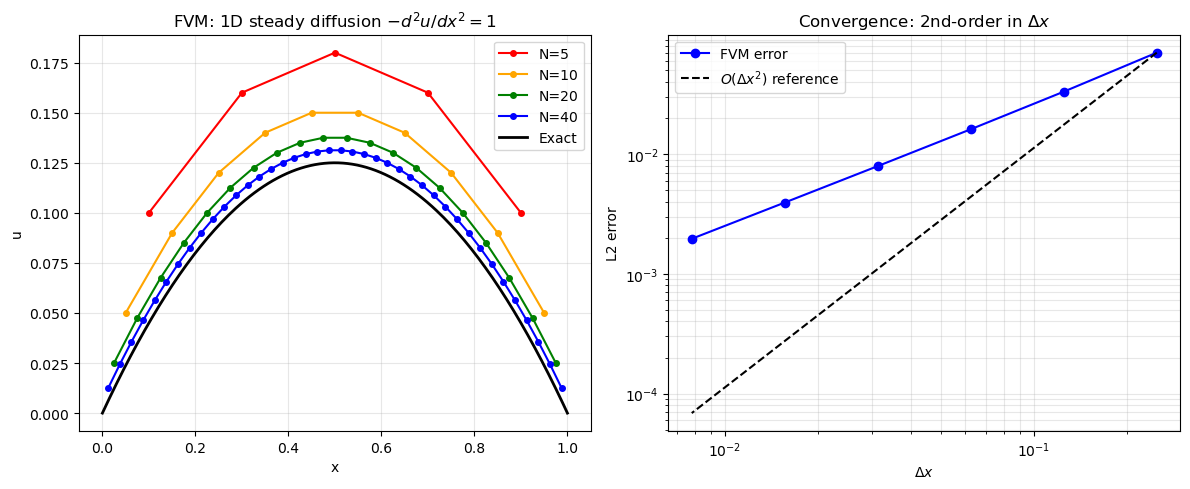

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# FVM for 1D steady diffusion: d²u/dx² = -S on [0,1]
# Boundary conditions: u(0)=0, u(1)=0
# Source term S = 1 → exact solution: u = x(1-x)/2

def fvm_1d_diffusion(N, alpha=1.0, S=1.0):
    """Solve -alpha * d²u/dx² = S on [0,1] with u(0)=u(1)=0 using FVM."""
    dx = 1.0 / N
    # Cell centres
    x_cells = np.linspace(0.5*dx, 1.0 - 0.5*dx, N)
    
    # Diffusion coefficient between cells: alpha * A / d
    # For uniform grid: D = alpha / dx
    D = alpha / dx
    
    # Build tridiagonal system
    # For interior cells: -D*u_{i-1} + 2D*u_i - D*u_{i+1} = S*dx
    # For boundary cells: add D*u_boundary (=0 here) to RHS
    
    A = np.zeros((N, N))
    b = np.ones(N) * S * dx
    
    for i in range(N):
        A[i, i] = 2*D
        if i > 0:
            A[i, i-1] = -D
        else:
            b[i] += D * 0.0  # u(0) = 0
        if i < N-1:
            A[i, i+1] = -D
        else:
            b[i] += D * 0.0  # u(1) = 0
    
    u = np.linalg.solve(A, b)
    return x_cells, u

# Exact solution
x_exact = np.linspace(0, 1, 200)
u_exact = x_exact * (1 - x_exact) / 2

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Solution accuracy
for N, color in zip([5, 10, 20, 40], ['red', 'orange', 'green', 'blue']):
    xc, uc = fvm_1d_diffusion(N)
    axes[0].plot(xc, uc, 'o-', color=color, markersize=4, label=f'N={N}')

axes[0].plot(x_exact, u_exact, 'k-', linewidth=2, label='Exact')
axes[0].set_xlabel('x'); axes[0].set_ylabel('u')
axes[0].set_title('FVM: 1D steady diffusion $-d^2u/dx^2 = 1$')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Convergence study
N_list   = [4, 8, 16, 32, 64, 128]
errors   = []
for N in N_list:
    xc, uc = fvm_1d_diffusion(N)
    u_ref  = xc * (1 - xc) / 2
    errors.append(np.sqrt(np.mean((uc - u_ref)**2)))

dx_list = [1.0/N for N in N_list]
axes[1].loglog(dx_list, errors, 'bo-', markersize=6, label='FVM error')
axes[1].loglog(dx_list, np.array(dx_list)**2 * errors[0]/dx_list[0]**2,
               'k--', label='$O(\\Delta x^2)$ reference')
axes[1].set_xlabel('$\\Delta x$')
axes[1].set_ylabel('L2 error')
axes[1].set_title('Convergence: 2nd-order in $\\Delta x$')
axes[1].legend()
axes[1].grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

In [2]:
# FVM for 1D unsteady advection: demonstrate exact conservation
N   = 60
L   = 1.0
dx  = L / N
x   = np.linspace(0.5*dx, L - 0.5*dx, N)
c   = 1.0
dt  = 0.8 * dx / c
nt  = 40

# Initial: top-hat — compute total mass before and after
u   = np.zeros(N)
u[(x >= 0.2) & (x <= 0.4)] = 1.0

mass_initial = np.sum(u) * dx

for _ in range(nt):
    # Upwind flux at right face of each cell
    flux = c * u  # upwind: use left cell (c>0)
    # Conservative update
    u[1:]  = u[1:]  - dt/dx * (flux[1:]  - flux[:-1])
    u[0]   = u[0]   - dt/dx * (flux[0]   - flux[-1])  # periodic

mass_final = np.sum(u) * dx

print(f"Mass before: {mass_initial:.10f}")
print(f"Mass after:  {mass_final:.10f}")
print(f"Change:      {abs(mass_final - mass_initial):.2e}  (FVM is exactly conservative!)")

Mass before: 0.2000000000
Mass after:  0.2000000000
Change:      0.00e+00  (FVM is exactly conservative!)


## Key Takeaways

- FVM integrates the conservation law over cells — never approximates derivatives inside cells.
- **Exact conservation** is guaranteed: the flux leaving one cell equals the flux entering the next.
- Face flux reconstruction is the art of FVM: upwind (stable, diffusive), central (accurate, sometimes unstable).
- FVM handles unstructured grids naturally — this is why OpenFOAM and Fluent use it.
- Second-order accuracy on uniform grids (same as central FDM), but conservative.

---

**Next**: Lesson 2.3 — Navier-Stokes Equations: full derivation and non-dimensionalisation.
